In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("healthcare_disease_prediction_2000.csv")
df.info()
df.describe()
print(df)

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Patient_ID                2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   str    
 3   BMI                       2000 non-null   float64
 4   Blood_Pressure_Systolic   2000 non-null   int64  
 5   Blood_Pressure_Diastolic  2000 non-null   int64  
 6   Cholesterol               2000 non-null   int64  
 7   Glucose_Level             2000 non-null   int64  
 8   Smoking                   2000 non-null   int64  
 9   Alcohol_Intake            2000 non-null   int64  
 10  Physical_Activity         2000 non-null   int64  
 11  Family_History            2000 non-null   int64  
 12  Heart_Disease             2000 non-null   int64  
 13  Diabetes                  2000 non-null   int64  
 14  Stroke             

In [24]:
data = df.replace(to_replace="Male", value = 1)

In [25]:
data = data.replace(to_replace="Female", value = 0)
data

,Patient_ID,Age,Gender,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol,Glucose_Level,Smoking,Alcohol_Intake,Physical_Activity,Family_History,Heart_Disease,Diabetes,Stroke
0,1,69,1,34.1,127,71,184,154,1,1,0,0,0,1,0
1,2,32,1,25.0,148,69,177,136,1,1,1,0,0,0,0
2,3,78,1,25.2,98,93,252,110,0,0,0,0,0,0,0
3,4,38,1,9.6,162,102,274,87,1,0,1,0,0,0,0
4,5,41,0,29.0,161,69,251,127,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,19,1,28.0,114,100,255,91,1,1,1,0,0,0,0
1996,1997,46,0,35.2,92,86,295,133,0,0,1,0,0,0,0
1997,1998,69,1,30.1,98,114,179,90,0,1,0,0,0,0,0
1998,1999,44,1,23.2,175,94,159,198,1,1,1,0,0,0,0


In [8]:
data.value_counts("Heart_Disease")

Heart_Disease
0    1839
1     161
Name: count, dtype: int64

In [9]:
print("Heart Disease Cases:\n", data["Heart_Disease"].value_counts())
print("Diabetes Cases:\n", data["Diabetes"].value_counts())
print("Stroke Cases:\n", data["Stroke"].value_counts())


Heart Disease Cases:
 Heart_Disease
0    1839
1     161
Name: count, dtype: int64
Diabetes Cases:
 Diabetes
0    1738
1     262
Name: count, dtype: int64
Stroke Cases:
 Stroke
0    1898
1     102
Name: count, dtype: int64


In [10]:
print("average age:\n", data["Age"].mean())
print("average bmi:\n", data["BMI"].mean())

average age:
 50.273
average bmi:
 26.977349999999998


Text(0, 0.5, 'Heart disease')

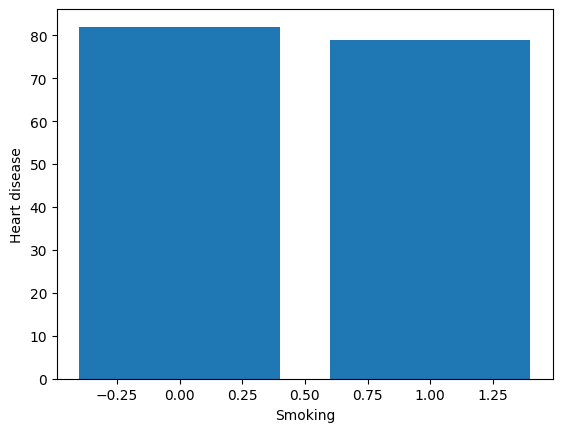

In [27]:
smoking_vs_heartdisease = data.groupby("Smoking")["Heart_Disease"].sum()  # total count

plt.figure()
plt.bar(smoking_vs_heartdisease.index, smoking_vs_heartdisease.values)
plt.xlabel("Smoking")
plt.ylabel("Heart disease")

Text(0.5, 0, 'Gender')

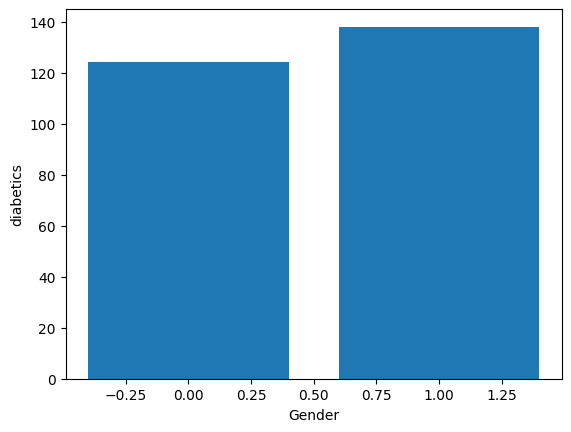

In [18]:
gender_vs_diabetics = data.groupby("Gender")["Diabetes"].sum()

plt.figure()
plt.bar(gender_vs_diabetics.index,gender_vs_diabetics.values)
plt.ylabel("diabetics")
plt.xlabel("Gender")

In [21]:
corr = data.corr(numeric_only=True)
print(corr)

                          Patient_ID       Age       BMI  \
Patient_ID                  1.000000 -0.038755 -0.001252   
Age                        -0.038755  1.000000  0.008606   
BMI                        -0.001252  0.008606  1.000000   
Blood_Pressure_Systolic    -0.006850 -0.009570  0.024552   
Blood_Pressure_Diastolic    0.028856 -0.023281 -0.021601   
Cholesterol                -0.023696 -0.004438  0.017941   
Glucose_Level              -0.019769 -0.013152  0.036943   
Smoking                    -0.000154  0.003408 -0.003040   
Alcohol_Intake              0.040486 -0.003997  0.030884   
Physical_Activity          -0.027184  0.037162  0.007914   
Family_History             -0.027180  0.022355  0.006112   
Heart_Disease              -0.007208  0.275734  0.031316   
Diabetes                   -0.013286 -0.004847  0.473932   
Stroke                     -0.002811  0.274775  0.021243   

                          Blood_Pressure_Systolic  Blood_Pressure_Diastolic  \
Patient_ID          

In [23]:
corr.loc["Age","Glucose_Level"]

np.float64(-0.013152391031456372)

Text(0, 0.5, 'Glucose Level')

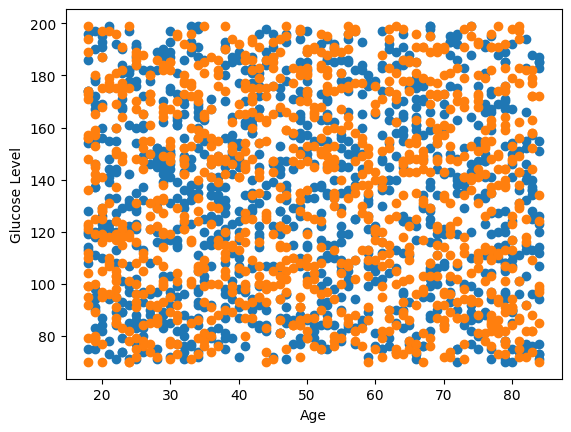

In [34]:
male = data[data['Gender'] == 1]
female = data[data['Gender'] == 0]

plt.scatter(male['Age'],male['Glucose_Level'], label = 'Male')
plt.scatter(female['Age'], female['Glucose_Level'], label = 'Male')
plt.legend
plt.xlabel("Age")
plt.ylabel("Glucose Level")

In [ ]:
high_risk = df[
    (df['Age']>80) &
    (df['BMI']>30) &
    
]